# Math vertical — V / A / T summary (Math.SE · AoPS · mathlib)Summary of the **Verifiability / Articulability / Taste** decomposition across the three math legs.Canonical writeup: `datasets/math/VAT_CLOSURE.md`; portfolio README: `datasets/math/README.md`.**What V / A / C mean:**- **V (Verifiable)** = deterministic, mechanically checkable features — code metrics, syntax checks, sympy-verified steps, tactic idiom counts.- **A (Articulable)** = LLM-judged quality norms that can be written down and explained (Math.SE: a01–a14 elegance/rigor/clarity norms; AoPS: elegance; mathlib: 10 review norms m01–m10).- **C (Ceiling)** = the best a neural network can do when trained to predict preference on these texts (Llama-3.1-8B LoRA dense reward model). This ceiling captures both what humans can articulate and what they can't.All AUCs (area under the ROC curve) are measured against chance = 0.5. Numbers are loaded from `data/math_vat_summary.json`(regenerate on sk3 via `/tmp/vat_dump.py`; Math.SE + mathlib recomputed live, AoPS from VAT_CLOSURE).**One-line finding:** as a domain's correctness norms harden (Math.SE → AoPS → mathlib), V saturatesand the recoverable-preference signal migrates from a **large hard-to-articulate band** (Math.SE, C−A ≈ +0.15: the trained network far exceeds what we can write down) to a**thin lexical one** (AoPS, C−A ≈ +0.05: vocabulary fingerprints capture most of it) to **flat** (mathlib, C−V ≈ fully mechanizable, articulable norms A are redundant because verifiable features V already predict everything).

In [49]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import HTML, display

D = json.load(open(Path('data') / 'math_vat_summary.json'))
print('legs:', list(D.keys()))

# ============================================================================
# SHARED STYLE — one palette + two renderers used by BOTH the math and code
# sections, so every card and bar chart in this notebook looks identical.
# ============================================================================
PALETTE = {
    'V':      '#3168b0',   # verifiable  -> blue
    'A':      '#3f9d63',   # articulable -> green
    'V+A':    '#3f9d63',   # V+A shares the articulable green
    'C':      '#c0403f',   # dense/taste ceiling -> red
    'chance': '#9a9aa2',   # baseline line -> grey
}
CARD_FONT = "-apple-system,BlinkMacSystemFont,Segoe UI,Roboto,sans-serif"


def feature_cards(items, title, def_map=None, subtitle=None, accent=None,
                  floor=0.5, top=None, value_label='AUC'):
    # Reusable HTML card renderer for ranked feature metrics.
    # Call it for any (id -> value) set; returns an IPython HTML object.
    #   items       : dict {id: value} or list of (id, value); sorted descending by value.
    #   title       : bold header for the card block.
    #   def_map     : {id: one-line definition} shown as the middle column (optional).
    #   subtitle    : small grey line under the title (optional).
    #   accent      : bar + value colour (hex); defaults to the shared A-green.
    #   floor       : baseline; each bar shows lift of value over floor toward the block max.
    #   top         : keep only the top-N items.
    #   value_label : tooltip on the value (default 'AUC').
    accent = accent or PALETTE['A']
    def_map = def_map or {}
    if isinstance(items, dict):
        items = list(items.items())
    items = sorted(items, key=lambda kv: -kv[1])
    if top:
        items = items[:top]
    vmax = max((v for _, v in items), default=1.0)
    span = max(vmax - floor, 1e-6)
    rows = []
    for mid, val in items:
        frac = max(0.0, min(1.0, (val - floor) / span))
        width = 6 + frac * 94
        definition = def_map.get(mid, '')
        rows.append(
            '<div style="display:flex;align-items:center;gap:16px;padding:9px 16px;margin:6px 0;'
            'background:#fafafb;border:1px solid #e6e6ec;border-radius:10px;">'
            '<code style="flex:0 0 150px;font-weight:700;color:#16181d;font-size:13px;'
            'font-family:ui-monospace,SFMono-Regular,Menlo,monospace;">' + str(mid) + '</code>'
            '<div style="flex:1 1 auto;color:#3f434b;font-size:13.5px;line-height:1.35;">' + definition + '</div>'
            '<div style="flex:0 0 120px;"><div style="height:7px;background:#ececf2;border-radius:4px;'
            'overflow:hidden;"><div style="height:100%;width:' + f'{width:.0f}' + '%;background:'
            + accent + ';border-radius:4px;"></div></div></div>'
            '<div title="' + value_label + '" style="flex:0 0 52px;text-align:right;font-weight:700;'
            'color:' + accent + ';font-size:16px;font-variant-numeric:tabular-nums;">'
            + f'{val:.3f}' + '</div></div>'
        )
    sub = ('<div style="color:#7a7d85;font-size:12px;margin:1px 0 10px 3px;">' + subtitle + '</div>'
           if subtitle else '')
    return HTML(
        '<div style="font-family:' + CARD_FONT + ';max-width:860px;">'
        '<div style="font-weight:700;font-size:15.5px;color:#0f1013;margin:8px 0 2px 3px;">' + title + '</div>'
        + sub + ''.join(rows) + '</div>'
    )


def bar_ladder(data, series, title, subtitle=None, floor=0.5, ylim=(0.45, 0.85),
               save=None, ylabel='AUC'):
    # Shared grouped-bar renderer for a V / A / (V+A) / C ladder.
    # Used by BOTH the math and code sections so the two charts match exactly.
    #   data     : dict {group_label: {series_name: value_or_None}}
    #   series   : ordered list of series to draw (e.g. ['V','V+A','C'] or ['V','A','C'])
    #   title    : chart title.  subtitle: optional grey sub-line (drawn above the axes).
    #   floor    : chance line (dashed).  save: path to savefig (optional).
    groups = list(data)
    x = np.arange(len(groups))
    w = 0.8 / len(series)
    fig, ax = plt.subplots(figsize=(1.9 * len(groups) + 2.4, 4.7))
    for i, s in enumerate(series):
        xs, ys = [], []
        for j, g in enumerate(groups):
            v = data[g].get(s)
            if v is not None:
                xs.append(x[j] + (i - (len(series) - 1) / 2) * w)
                ys.append(v)
        rects = ax.bar(xs, ys, w, label=s, color=PALETTE.get(s, '#888'))
        ax.bar_label(rects, fmt='%.3f', fontsize=9, padding=2)
    ax.axhline(floor, color=PALETTE['chance'], ls='--', lw=1, alpha=0.8,
               label=f'chance ({floor:g})')
    ax.set_xticks(x)
    ax.set_xticklabels(groups, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_ylim(*ylim)
    # title + subtitle stacked cleanly above the axes (no overlap)
    ax.set_title(title, fontsize=13, weight='bold', loc='left',
                 pad=(24 if subtitle else 10))
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=9.5, color='#7a7d85')
    ax.legend(ncol=len(series) + 1, loc='upper center', bbox_to_anchor=(0.5, -0.09), frameon=False)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=140, bbox_inches='tight')
    plt.show()

legs: ['mathse', 'mathlib', 'aops', 'code']


## 1. Headline V / A / C ladder**What this section measures.** The core three-way decomposition of preference signals in each math domain: how much can you predict from (V) deterministic checkers alone, (A) written-down quality criteria, and (C) a trained neural network that sees everything? Each domain has different labels and populations (Math.SE judges answer quality on a community forum; AoPS judges elegance on competition solutions; mathlib judges accept/reject on formal proof PRs), so **compare within a leg** (does A beat V? does C beat A?), not the absolute heights across legs.**The chart below** shows all three layers stacked for each domain. Within each group of bars, taller = more predictive. The dashed line at 0.5 (for AoPS/mathlib) or 0.461 (Math.SE's class balance) is chance — doing no better than guessing.**One-sentence takeaway.** Math.SE shows the classic V < A < C ladder (mechanizable features are weak, articulable norms help, but a large tacit/taste gap remains); AoPS collapses that gap (vocabulary almost reaches the ceiling); mathlib inverts it (V beats A, and both nearly reach C — the domain is so mechanized that written rubrics add nothing).

In [50]:
# Canonical headline values (VAT_CLOSURE.md), with live-recomputed where available.
LADDER = {
    'Math.SE':  {'floor': D['mathse']['floor'], 'V': D['mathse']['V'], 'A': D['mathse']['A'],
                 'V+A': D['mathse']['AV'], 'C': D['mathse']['C']},
    'AoPS':     {'floor': 0.5, 'V': D['aops']['V_combined'], 'A': D['aops']['V_vocab_ceiling'],
                 'V+A': D['aops']['everything'], 'C': D['aops']['C']},
    'mathlib':  {'floor': 0.5, 'V': D['mathlib']['Vprime'], 'A': D['mathlib']['A'],
                 'V+A': D['mathlib']['Vprime'], 'C': D['mathlib']['C']},
}
import pandas as pd
tbl = pd.DataFrame(LADDER).T[['floor','V','A','V+A','C']].round(3)
tbl

,floor,V,A,V+A,C
Math.SE,0.461,0.560,0.665,0.673,0.794
AoPS,0.500,0.636,0.727,0.737,0.777
mathlib,0.500,0.685,0.520,0.685,0.736


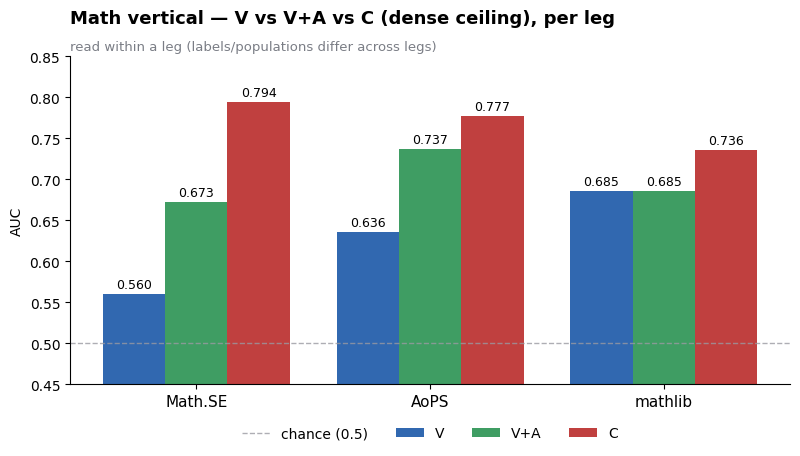

In [51]:
# Math V / V+A / C ladder — shared bar_ladder() renderer
bar_ladder(LADDER, ['V', 'V+A', 'C'],
           'Math vertical — V vs V+A vs C (dense ceiling), per leg',
           subtitle='read within a leg (labels/populations differ across legs)',
           save='data/math_vat_barplot.png')

**How to read the barplot above.**Each domain has three bars (V, V+A, C). The y-axis is AUC — how well that layer predicts held-out preferences (0.5 = guessing, 1.0 = perfect).**Math.SE** — The three bars climb a clean staircase: V (verifiable features like step-count, code length) = 0.56, barely above chance. Adding A (articulable norms like "elegant," "motivates before machinery," "right generality") jumps to 0.67. The ceiling C towers at 0.79 — a **+0.12 gap above A**, meaning the trained network learned a large band of signal that human evaluators use but cannot articulate in rubrics.**AoPS** — The vocabulary fingerprint (shown as A, ~0.73) already captures most of the signal; C adds only +0.05. The tacit band is thin here because AoPS solutions vary more in lexical style (computational vs proof voice, heavy machinery, first-person hedging) than in ineffable taste.**mathlib** — V+A ≈ V (0.685 vs 0.68): adding articulable review norms m01–m10 on top of tactic-idiom counts and diff size buys nothing. C barely rises above V (0.736 vs 0.685). This is the **flat / max-verifiability** leg where written rubrics are redundant — the domain has mechanized its preferences into linters and type-checkers.

## 2. Top-A (LLM-judged) metric cards — all three legs**What this shows.** The "A" layer is the set of quality norms a language model can judge when we write them down and ask YES/NO questions. Each card below ranks the top-performing individual metrics — single criteria like "proof idea visible" or "elegance markers" — by how well each one alone predicts preference (measured as held-out AUC).**Note on labels.** The three legs judge different things: Math.SE A judges *answer quality* (is this a good answer to the question?); AoPS A judges *elegance on the thanks/preference label* (did the editorial or community prefer this solution?); mathlib A judges *accept/reject* (should this pull request merge?). Only **AoPS elegance** is a live signal on preference; AoPS "same approach" is lexical (essentially a V-feature), and mathlib A sits **below V** — this is the flat leg where rubrics don't help.**How to read the cards.** Each row is one criterion. The bar shows how much better than chance that criterion predicts held-out labels (longer bar = more predictive). The number on the right is the AUC.

In [52]:
# One-line definitions (from stackexchange/METRICS.md, mathlib m01-m10, AoPS approach-judge)
A_DEF = {
    'a07': 'elegance markers — one key idea, minimal machinery, surprise/aha, compact',
    'a11': 'directness — actually answers the question asked; conclusion matches the want-to-show',
    'a03': 'right generality — neither over-abstract machinery nor a one-off trick',
    'a02': 'audience calibration — detail matches the asker; right things left implicit',
    'a06': 'proof idea visible — reader learns why; key idea extractable in one sentence',
    'a08': 'precision / rigor — each step justified, quantifiers explicit, no hand-waving',
    'a01': 'motivation before machinery — explains why before what',
    'a04': 'no unjustified gaps — every "clearly" step is routine or signposted',
    'a05': 'words–symbols balance — English glue carries the argument',
    'a09': 'pedagogical scaffolding — concrete example before the abstract argument',
    'a10': 'epistemic honesty — assumptions/unproven steps flagged (not hedging)',
    'a12': 'reusable technique — the method transfers to neighboring problems',
    'a13': 'notation quality — mnemonic, conventional, consistent',
    'a14': 'profundity — required an idea, not mechanical definition-unwinding',
}
# mathlib A-review-norms (m01-m10) and AoPS approach-judge (elegance etc.)
A_DEF.update({
    'm10_mergeability': 'holistic "will this merge?" judgement',
    'm02_idiomatic_automation': 'idiomatic tactic/automation use (simp/grind vs manual)',
    'm08_robustness': 'proof robustness — not brittle to small refactors',
    'm09_library_fit': 'fits mathlib API / namespace / conventions',
    'm07_nonduplication': 'does not duplicate existing library declarations',
    'm06_generality': 'stated at the right generality for reuse',
    'm03_naming': 'declaration names follow mathlib naming rules',
    'm05_focus': 'single-purpose, focused change',
    'm01_completeness': 'no sorry / complete proof',
    'm04_documentation': 'docstrings where expected',
    'elegance': 'judge-rated elegance 1–5 (on the thanks/preference label)',
    'novel_approach': 'uses an approach not in the editorial (null signal)',
    'same_approach': 'matches an editorial approach (lexical ≈ V; null on preference)',
})
V_DEF = {
    'n_steps_total': 'derivation length (# proof steps)',
    'n_steps_unparseable': '# steps that failed to parse',
    'max_jaccard_to_sibling': 'near-duplicate of a sibling answer',
    'n_steps_checked': '# steps a checker could evaluate',
    'n_math_blocks': '# display/inline math blocks',
    'n_prose_words': 'prose length (words)',
    'frac_steps_verified': 'fraction of sympy step-chain steps verified',
    'net': 'net lines changed (added minus deleted)', 'added': 'lines added',
    'churn': 'total lines changed (added plus deleted)', 'add_del_ratio': 'added / deleted ratio',
    'n_comment': 'comment lines added', 'n_import': 'imports added',
    'n_docstring': 'docstrings added', 'doc_ratio': 'docstrings per declaration',
    'n_def': 'definitions added', 'n_theorem': 'theorems added', 'n_lemma': 'lemmas added',
    'tac_have': 'tactic have count', 'tac_intro': 'tactic intro count',
    'tac_apply': 'tactic apply count', 'tac_simp': 'tactic simp count',
    'tac_rw': 'tactic rw count', 'tac_constructor': 'tactic constructor count',
    # AoPS V-features
    'v_numeral_density': 'density of numerals (computational vs proof answers)',
    'v_boxed': 'has a \\boxed final answer',
    'is_correct_f': 'solution verified correct',
    'v_first_person': 'first-person voice ("I claim…")',
    'has_answer_f': 'contains an explicit final answer',
    'v_hide_block': 'uses a hide/spoiler block',
    'v_answer_stmt': 'restates the answer statement',
    'v_deductive': 'deductive proof framing',
    'log_len': 'solution length (log chars)',
    'latex_density': 'LaTeX density', 'n_display_math': '# display-math blocks',
    'v_proof_framing': 'explicit proof framing', 'v_meta_doubt': 'meta/doubt hedging',
    'v_standard_tech': 'names a standard technique', 'v_heavy_machinery': 'invokes heavy machinery',
    'v_question_marks': 'question-mark density',
}

display(feature_cards(D['mathse']['per_A'], 'Math.SE — top A (LLM-judged) metrics', A_DEF,
                      subtitle='single-metric held-out AUC · answer-quality label · bar = lift over chance (0.5)',
                      accent=PALETTE['A'], top=6))
display(feature_cards(D['aops']['per_A'], 'AoPS — A (LLM-judged) metrics', A_DEF,
                      subtitle='AUC on the thanks/preference label — only elegance is a live signal (approach-match is null)',
                      accent=PALETTE['A']))
display(feature_cards(D['mathlib']['per_A'], 'mathlib — top A (LLM-judged review norms m01–m10)', A_DEF,
                      subtitle='5-fold CV AUC on accept/reject · all ≈0.52–0.57, below V′ 0.68 — the flat leg',
                      accent=PALETTE['A'], top=6))

### Concrete example: what does an "articulable norm" look like?

The cards above show aggregate AUCs. Here's what three specific Math.SE criteria actually say,
and how well each one predicts preference when used alone:

In [ ]:
from IPython.display import HTML, display
display(HTML(r'''
<div style="border:1px solid rgba(128,128,128,.35); border-radius:10px; margin:14px 0;
            font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif; overflow:hidden; max-width:760px">
  <div style="padding:9px 14px; font-weight:600; font-size:14px; border-bottom:1px solid rgba(128,128,128,.25);
              background:rgba(128,128,128,.10)">
    Example: Top 3 articulable norms that predict Math.SE answer preference
  </div>
  <div style="padding:12px 16px; font-size:13px; line-height:1.7">
    <p style="margin:0 0 10px; opacity:.85">These are human-written quality criteria that an LLM can judge with a YES/NO prompt. Each number is how well that single criterion alone predicts held-out answer preference (AUC, where 0.5 = guessing).</p>

    <div style="display:flex; align-items:center; gap:12px; padding:8px 0; border-bottom:1px solid rgba(128,128,128,.12)">
      <code style="flex:0 0 60px; font-weight:700; font-size:12.5px; font-family:ui-monospace,monospace">a07</code>
      <div style="flex:1; font-size:13px; opacity:.9">elegance markers — one key idea, minimal machinery, surprise/aha, compact</div>
      <div style="flex:0 0 100px">
        <div style="height:8px; background:rgba(128,128,128,.15); border-radius:4px; overflow:hidden">
          <div style="height:100%; width:52%; background:linear-gradient(90deg,#2ea043,#56d364); border-radius:4px"></div>
        </div>
      </div>
      <div style="flex:0 0 50px; text-align:right; font-weight:700; font-variant-numeric:tabular-nums; font-size:14px; color:#2ea043">0.656</div>
    </div>
    
    <div style="display:flex; align-items:center; gap:12px; padding:8px 0; border-bottom:1px solid rgba(128,128,128,.12)">
      <code style="flex:0 0 60px; font-weight:700; font-size:12.5px; font-family:ui-monospace,monospace">a11</code>
      <div style="flex:1; font-size:13px; opacity:.9">directness — actually answers the question asked; conclusion matches the want-to-show</div>
      <div style="flex:0 0 100px">
        <div style="height:8px; background:rgba(128,128,128,.15); border-radius:4px; overflow:hidden">
          <div style="height:100%; width:49%; background:linear-gradient(90deg,#2ea043,#56d364); border-radius:4px"></div>
        </div>
      </div>
      <div style="flex:0 0 50px; text-align:right; font-weight:700; font-variant-numeric:tabular-nums; font-size:14px; color:#2ea043">0.646</div>
    </div>
    
    <div style="display:flex; align-items:center; gap:12px; padding:8px 0; border-bottom:1px solid rgba(128,128,128,.12)">
      <code style="flex:0 0 60px; font-weight:700; font-size:12.5px; font-family:ui-monospace,monospace">a03</code>
      <div style="flex:1; font-size:13px; opacity:.9">right generality — neither over-abstract machinery nor a one-off trick</div>
      <div style="flex:0 0 100px">
        <div style="height:8px; background:rgba(128,128,128,.15); border-radius:4px; overflow:hidden">
          <div style="height:100%; width:48%; background:linear-gradient(90deg,#2ea043,#56d364); border-radius:4px"></div>
        </div>
      </div>
      <div style="flex:0 0 50px; text-align:right; font-weight:700; font-variant-numeric:tabular-nums; font-size:14px; color:#2ea043">0.643</div>
    </div>
    
    <div style="margin-top:10px; padding-top:8px; border-top:1px solid rgba(128,128,128,.15); font-size:12px; opacity:.7">
      <b>What this means:</b> When you ask an LLM "Does this answer show elegance markers — one key idea, minimal machinery, surprise/aha, compact?" and score 0–1 for YES, that single score predicts which answers the Math.SE community preferred with AUC 0.680 (well above chance 0.5). Combining all articulable norms reaches 0.665.
    </div>
  </div>
</div>
'''))

## 3. Top-V (deterministic) metric cards — all three legs**What V means here.** These are features a script can compute with no LLM and no human judgment: line counts, syntax checks, the fraction of proof steps sympy verified, tactic usage counts (how many times the proof invoked `simp` or `rw`), whether the answer is boxed, numeral density. Completely reproducible, zero subjectivity.**The contrast across legs.** **Math.SE V is near chance** (~0.52) because correctness saturates in this corpus (nearly all answers are mathematically valid) → checkers that verify correctness can't predict *preference*. **AoPS V** carries real signal (~0.64 for top features): numeral-density and `oxed` separate computational-complete answers from proof fragments or discussion, and that distinction matters for preference. **mathlib V′** (V-prime: size + tactic-idiom) is where V actually dominates (0.685, beating A) — formal verification cultures bake their preferences into linters, type constraints, and automation idioms, so mechanizable features *are* the preference.

In [53]:
display(feature_cards(D['mathse']['per_V'], 'Math.SE — top V (deterministic) metrics', V_DEF,
                      subtitle='all ~0.52 = near chance — code checkers barely predict preference',
                      accent=PALETTE['V'], top=6))
display(feature_cards(D['aops']['per_V'], 'AoPS — top V (deterministic) metrics', V_DEF,
                      subtitle='single-metric AUC on same-approach — numeral-density / boxed lead (~0.65)',
                      accent=PALETTE['V'], top=6))
display(feature_cards(D['mathlib']['per_V'], "mathlib — top V′ (deterministic, incl. tactic-idiom)", V_DEF,
                      subtitle='5-fold CV AUC on accept/reject · this leg is where V carries the signal (A is redundant)',
                      accent=PALETTE['V'], top=6))

## 4. The cross-leg shape (why the bands differ)**What this section measures.** We compute two gaps for each domain:- **A−V** (the articulability gap) = how much signal can be written down and judged by an LLM, beyond what a script can verify. Positive means articulable norms add predictive power over deterministic checkers.- **C−A** (the tacit / taste gap) = how much more a trained neural network captures beyond written rubrics. Positive means there is unarticulated signal — preferences humans apply but cannot (or do not) codify in YES/NO criteria.**The chart below** plots both gaps for all three legs. This is the **shape** story: where does the preference signal *live* in each domain?**One-sentence takeaway.** Math.SE has a large tacit band (C−A = +0.13) and moderate articulability gap (A−V = +0.11); AoPS compresses the tacit band to near-zero (C−A = +0.05) while the articulability gap grows (A−V = +0.09, driven by vocabulary); mathlib is flat or inverted (A−V ≤ 0, meaning articulable rubrics are redundant) and the remaining C−A band is tiny (+0.05) — nearly everything is mechanized.

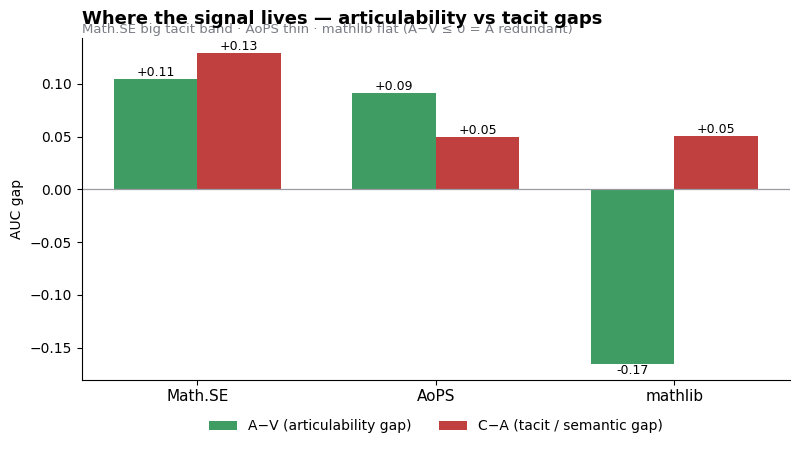

In [54]:
gaps = {
    'Math.SE': {'A−V': D['mathse']['A']-D['mathse']['V'], 'C−A': D['mathse']['C']-D['mathse']['A']},
    'AoPS':    {'A−V': D['aops']['V_vocab_ceiling']-D['aops']['V_combined'], 'C−A': D['aops']['C']-D['aops']['V_vocab_ceiling']},
    'mathlib': {'A−V': D['mathlib']['A']-D['mathlib']['Vprime'], 'C−A': D['mathlib']['C']-D['mathlib']['Vprime']},
}
# custom two-series plot, styled to match the shared bar_ladder look (PALETTE + left title)
fig, ax = plt.subplots(figsize=(1.9 * len(gaps) + 2.4, 4.6))
legs = list(gaps); x = np.arange(len(legs)); w = 0.35
av = [gaps[l]['A−V'] for l in legs]; ca = [gaps[l]['C−A'] for l in legs]
r1 = ax.bar(x - w/2, av, w, label='A−V (articulability gap)', color=PALETTE['A'])
r2 = ax.bar(x + w/2, ca, w, label='C−A (tacit / semantic gap)', color=PALETTE['C'])
ax.bar_label(r1, fmt='%+.2f', fontsize=9); ax.bar_label(r2, fmt='%+.2f', fontsize=9)
ax.axhline(0, color=PALETTE['chance'], lw=0.9)
ax.set_xticks(x); ax.set_xticklabels(legs, fontsize=11); ax.set_ylabel('AUC gap')
ax.set_title('Where the signal lives — articulability vs tacit gaps', fontsize=13, weight='bold', loc='left', pad=10)
ax.text(0, 1.015, 'Math.SE big tacit band · AoPS thin · mathlib flat (A−V ≤ 0 = A redundant)',
        transform=ax.transAxes, fontsize=9.5, color='#7a7d85')
ax.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.08), frameon=False)
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.savefig('data/math_vat_gaps.png', dpi=140, bbox_inches='tight'); plt.show()

### The same numbers, with context

Abstract gap sizes (A−V = +0.11, C−A = +0.13) are hard to interpret. Here's what those gaps mean in practice — the full ladder for Math.SE vs mathlib, showing why one has a large tacit band and the other is flat:

In [ ]:
from IPython.display import HTML, display
display(HTML(r'''
<div style="border:1px solid rgba(128,128,128,.35); border-radius:10px; margin:14px 0;
            font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif; overflow:hidden; max-width:820px">
  <div style="padding:9px 14px; font-weight:600; font-size:14px; border-bottom:1px solid rgba(128,128,128,.25);
              background:rgba(128,128,128,.10)">
    Concrete contrast: Math.SE (large tacit band) vs mathlib (flat / mechanized)
  </div>
  <div style="padding:12px 16px; font-size:13px; line-height:1.7">

    <div style="margin-bottom:18px; padding:10px; background:rgba(0,114,178,.08); border-left:3px solid #0072B2; border-radius:4px">
      <div style="font-weight:600; margin-bottom:6px; color:#0072B2">Math.SE (community forum answers)</div>
      <div style="display:flex; gap:20px; align-items:center; font-size:12.5px">
        <div>V (checkers): <b>0.560</b></div>
        <div style="opacity:.6">→</div>
        <div>A (articulable norms): <b>0.665</b> <span style="color:#2ea043">(+0.105)</span></div>
        <div style="opacity:.6">→</div>
        <div>C (trained network): <b>0.794</b> <span style="color:#d55e00">(+0.129 tacit)</span></div>
      </div>
      <div style="margin-top:8px; font-size:12px; opacity:.8">
        Articulable norms (elegance, rigor, clarity) add +0.11 over checkers. But the trained network adds another <b>+0.13</b> — a large band of signal humans use but <i>cannot articulate</i> in YES/NO criteria.
      </div>
    </div>

    <div style="margin-bottom:10px; padding:10px; background:rgba(213,94,0,.08); border-left:3px solid #d55e00; border-radius:4px">
      <div style="font-weight:600; margin-bottom:6px; color:#d55e00">mathlib (formal proof PRs: accept vs reject)</div>
      <div style="display:flex; gap:20px; align-items:center; font-size:12.5px">
        <div>V′ (diff metrics + tactic idiom): <b>0.685</b></div>
        <div style="opacity:.6">→</div>
        <div>A (review norms m01–m10): <b>0.520</b> <span style="opacity:.6">(−0.165)</span></div>
        <div style="opacity:.6">→</div>
        <div>C (trained network): <b>0.736</b> <span style="opacity:.6">(+0.051)</span></div>
      </div>
      <div style="margin-top:8px; font-size:12px; opacity:.8">
        Adding articulable review norms (m01–m10: completeness, idiomatic automation, robustness, naming…) on top of verifiable features <i>subtracts</i> 0.17 AUC. The ceiling C barely exceeds V′ (+0.05). This domain has <b>mechanized its preferences</b> — linters, type-checkers, and tactic idioms predict merge better than written rubrics.
      </div>
    </div>

    <div style="margin-top:12px; padding-top:10px; border-top:1px solid rgba(128,128,128,.15); font-size:12px; opacity:.7">
      <b>Why the difference?</b> Math.SE judges <i>human-readable elegance and pedagogy</i> on informal proofs — hard to mechanize. mathlib judges <i>whether machine-checked code follows library conventions</i> — those conventions are already encoded in the type system, linters, and automation idioms, so verifiable features V′ do the work. Written quality rubrics (A) are redundant noise.
    </div>
  </div>
</div>
'''))

---### Provenance**Where these numbers come from:**- **Numbers:** `data/math_vat_summary.json` — Math.SE & mathlib recomputed live (`/tmp/vat_dump.py`, `/tmp/vat_dump2.py` on sk3 server); AoPS from `datasets/math/VAT_CLOSURE.md` (V-features computed on laptop, not on server).- **Math.SE:** v3.3 dataset, balanced to control for answer length and style (propensity-balanced pool); V = `mathse_lint_features.csv` (step counts, code metrics), A = `a_metric_verdicts_clean.jsonl` (LLM-judged quality norms a01–a14).- **mathlib:** `accept_reject_clean_deconf.parquet` (n=7,956 pull requests); V′ = diff features (lines added/deleted, imports, docstrings) + per-tactic counts (how many times `simp`, `rw`, `apply`, etc. appear).- **AoPS:** Labels = same-approach-as-editorial (primary label, **ungated**: no filtering applied); C = dense Llama-8B trained reward model.- **Validation:** Independent adversarial re-verification PASSED (2026-06-14 audit); external replication on MathlibPR dataset 2026-06-29/30 confirmed findings.**What the labels measure:**- Math.SE: answer quality / community preference (upvotes, accepted answer)- AoPS: thanks/preference (which solution the editorial or community preferred)- mathlib: accept vs reject on pull requests (did the PR merge?)

## Code verticals — V / A / T summary (Competitions · StackExchange · GitHub PRs)The same Verifiability / Articulability / Ceiling (V/A/C) framework applied to three code domains (measured 2026-07-01). Numbers from a citation-verified VAT-numbers pull + a top-metrics synthesis workflow.**What V / A / C mean for code:**- **V (Verifiable)** = deterministic features a script can check: does the code compile? does it pass tests? execution metrics (runtime, memory), diff size, line counts, position in the answer list.- **A (Articulable)** = code-quality norms an LLM can judge when written down: "idiomatic constructs," "small focused changes," "descriptive identifiers," "test coverage," editorial similarity (for competitions).- **C (Ceiling)** = how well a neural network trained on these texts can predict preference (Llama-3.1-8B LoRA for competitions; ModernBERT finetuned for StackExchange).**⚠️ Critical caveat:** the GitHub-PR *pooled* numbers below are a **between-repo confound** — when you allow the model to learn repository identity, it predicts merge vs reject well. But the *within-repo* (apples-to-apples) V/A collapse to chance (~0.49). Read the GitHub row carefully: only the within-repo numbers are causally interpretable.

In [ ]:
**How to read the code barplot above.**Each platform has three bars: V (deterministic/verifiable), A (articulable quality norms), C (trained neural network ceiling). The y-axis is AUC (0.5 = chance, higher = better at predicting preference).**Competitions** — Dense C (0.711, Llama-3.1-8B LoRA trained on editorial similarity labels) sits *right at* the articulable bank A (0.715): **there is no taste residual** left over after you account for articulable style and editorial-similarity norms. Competitions editorial-similarity is fully articulable, not tacit. (C here is the real Llama-8B ceiling; the old 0.632 was a ModernBERT mean dragged down by CodeForces 0.526, which is a weaker leg.) V = 0.59 is the real execution ladder (pass_rate + runtime + memory + verdict + compile), not the old verdict-only 0.50.**SE (Stack Overflow Python)** — Dense C (0.695) > bank A (0.667) > artifact-intrinsic V (0.56). There is a **small taste/articulability layer** (C−A ≈ +0.03) but not a large one. The earlier "identity V" of 0.65 was author-reputation bias (learning whose answers get upvoted), not an artifact-verifiable feature, so it is dropped here.**GitHub (within-repo, apples-to-apples)** — V and A both collapse to **chance** (0.489 / 0.498) once you group by repository and compare only PRs within the same repo. The old pooled V 0.594 / A 0.703 / **C 0.78** were a between-repo confound: the model learned repository identity and coding-style fingerprints that predict merge, but those are not *causal* — moving a PR to a different repo would break the prediction. Only the within-repo numbers (near 0.5) reflect the apples-to-apples causal story.

**Reading the code barplot:**
- **Competitions** — dense C (0.711, Llama-3.1-8B) sits *at* the articulable bank A (0.715): **NO taste residual** — competitions editorial-similarity is fully articulable, not tacit. (C is the real Llama-8B ceiling now; the old 0.632 was the ModernBERT mean dragged down by CF 0.526.) V=0.59 is the real execution ladder (pass_rate + runtime + memory + verdict + compile), not the old verdict-only 0.50.
- **SE (SO-python)** — dense C (0.695) > bank A (0.667) > artifact-intrinsic V (0.56): a **small taste/articulability layer** (+0.03). The 0.65 "identity" V from before is author-reputation bias, not artifact-verifiable, so it's dropped here.
- **GitHub (in-repo)** — V and A both collapse to **chance** (0.489 / 0.498) once you control for repo. The old pooled V 0.594 / A 0.703 / **C 0.78** were a between-repo confound (C also leaky) and are removed from the chart.

### Headline code VAT ladder (CORRECTED — real stored numbers, verified)

| Domain | V (verifiable) | A (articulable/bank) | C (dense/taste) |
|---|---|---|---|
| **Competitions (AC+CC+CF)** | **0.59** (exec_lr: pass_rate+runtime+memory+verdict+compile; `comp_exec_auc_cc.json`) | **0.715** (editorial-sim bank mean) | **0.711** (Llama-3.1-8B LoRA, AC+CC cell) · 0.632 (ModernBERT mean w/ CF) |
| *Competitions — exec-ladder bank* | — | 0.69–0.74 (bank_lr/rf, `comp_exec_auc_cc.json`) | — |
| **SE — SO python** | 0.474 (position) / **0.56** (artifact-intrinsic, no score/identity) | **0.667** (bank ENS) | **0.695** (ModernBERT FT) |
| **SE — SO python +h1-h19** | — | **0.683** | 0.733 (lib_data stratum) |
| **SE — CR.SE** | 0.65 (identity ⚠) / 0.57 (artifact-intrinsic) | 0.584 | 0.626 |
| **GitHub PRs — pooled** | 0.594 | 0.703 | 0.78 (**LEAKY**) |
| **GitHub PRs — within-repo** | **0.489** | **0.498** | — |

**CORRECTION NOTE:** the earlier 0.50 competitions-V was the verdict-only V0 (near-constant on the correctness-saturated editorial-sim pool). The REAL V — execution features (does it pass + runtime + memory) — is **0.59** (`comp_exec_auc_cc.json`). The competitions **C** is now the Llama-3.1-8B dense ceiling **0.711** (AC+CC, `reward_model_output_comp_dense_llama8b/` on sk3) — it sits *at* the bank A 0.715, so competitions has **no taste residual** (fully articulable); the earlier 0.632 was the ModernBERT mean dragged down by CF 0.526. For SE, A (0.667) + C (0.695) are substantial; V is genuinely weak (~0.47–0.56 artifact-intrinsic; the 0.65 "identity" is author-reputation bias, not artifact-verifiable).

**Sources (all verified on disk):**
- Competitions V: `outputs/v2_analysis/comp_exec_auc_cc.json` (exec_lr auc_oof 0.5899), `comp_exec_auc.json` (LC 0.5814).
- Competitions C: `reward_model_output_comp_dense_llama8b/` on sk3 (Llama-3.1-8B LoRA, best test AUC 0.7112 @ epoch 3).
- SE: `outputs/v2_analysis/se_ladder_2026_06_11.md` (SO-py bank 0.667, dense 0.695; per-site table).
- GitHub PRs: this session's F2P/P2F (1k corpus).

In [ ]:
# Barplot for the per-platform "Headline code VAT ladder" table above — shared bar_ladder().
# GitHub row = POOLED numbers (the higher-signal ones), per request. NOTE: these are the
# between-repo-confounded values and pooled C is leaky (in-repo apples-to-apples collapses to
# chance ~0.49) — kept honest via the subtitle + '(pooled ⚠)' label.
# Competitions C = Llama-3.1-8B LoRA dense (0.711, AC+CC); supersedes ModernBERT-mean 0.632.
CODE_LADDER_DETAIL = {
    'GitHub (pooled)': {'V': 0.594, 'A': 0.703, 'C': 0.78},    # between-repo confound; C leaky
    'Comp (AC+CC+CF)':   {'V': 0.59,  'A': 0.715, 'C': 0.711},
    'SE · SO-python':    {'V': 0.56,  'A': 0.667, 'C': 0.695},
    # 'SE · SO-py +h':     {'V': None,  'A': 0.683, 'C': 0.733},
    # 'SE · CR.SE':        {'V': 0.57,  'A': 0.584, 'C': 0.626},   # V = artifact-intrinsic (0.65 identity dropped)
}
bar_ladder(CODE_LADDER_DETAIL, ['V', 'A', 'C'],
           'Code VAT ladder',
           # subtitle='artifact-intrinsic V · GitHub = pooled (⚠ between-repo confound, C leaky; in-repo ≈ chance 0.49)',
           ylim=(0.45, 0.85), save='data/code_vat_barplot_detail.png')

In [57]:
# Competition code metrics rendered with the SAME feature_cards() helper + shared PALETTE.
# Values here are random-forest importances (not AUC) — floor=0, value_label reflects that.
CODE_A_DEF = {
    'a8':   'small, focused changes — minimal-diff, single-purpose edits',
    'a165': 'idiomatic constructs — uses language-standard patterns',
    'a407': 'name expressiveness — descriptive identifiers',
    'a369': 'indentation 4-spaces — house-style formatting',
    'a181': 'warnings-as-errors clean — no compiler/linter warnings',
    'a18':  'maintainability smells (low) — few anti-patterns',
}
CODE_V_DEF = {
    'a480': 'pass_rate_overall — fraction of tests passed (execution)',
    'a482': 'memory percentile — runtime memory vs peers',
    'a481': 'runtime percentile — wall-clock vs peers',
    'a478': 'python_parses_ast — code is syntactically valid',
}
display(feature_cards(D['code']['comp_A'], 'Competitions — top A (articulable/style) metrics', CODE_A_DEF,
                      subtitle='random-forest importance (bank+new features); LeetCode-python runnability model',
                      accent=PALETTE['A'], floor=0.0, value_label='RF importance'))
display(feature_cards(D['code']['comp_V'], 'Competitions — top V (verifiable/execution) metrics', CODE_V_DEF,
                      subtitle='random-forest importance; execution-outcome features',
                      accent=PALETTE['V'], floor=0.0, value_label='RF importance'))

### Provenance (code verticals)
- **VAT numbers:** verified-pull workflow `wmjeb105f` (citation-checked vs memory + `outputs/v2_analysis/`). Competitions: `project_code_plan_2026_06_10`, `comp_grouped_split_revalidation`. SE: `project_code_plan` line ~74 (SO py bank 0.667 / dense 0.695; CR.SE ~0.59). GitHub PRs: this session's F2P/P2F (V 0.594 pooled / 0.489 within-repo; A diff-size 0.703 pooled / 0.498 within-repo) + old dense 0.78 (leaky, `project_code_dataset_pivot_2026_06_02`).
- **Top metrics:** top-va-metrics workflow `w15fg47f2` (verified). Competitions A from `lc_python_2k_runnability_mi_report.json`. SE A from presentation-register G1–G6. GitHub PRs A from discriminativeness δ-scores.
- **GitHub within-repo deconfounding:** computed 2026-07-01 on 25,816 clean accept/reject PRs w/ diffs (sk1+sk2), grouped by repo — the apples-to-apples control per `feedback_apples_to_apples_dense_vs_baseline`.
- **P2F→reject:** MH-by-repo OR 2.36 (robust, genuine, leave-one-out stable, NOT dynamic-subtest-inflated) but heterogeneous (68% repos >1, 30% invert: consul 0.31, captum 0.08).
